# 02. Exploratory Data Analysis for Seller ESG Scoring

Notebook này thực hiện EDA chuyên sâu trên dataset đã được làm sạch nhằm:

- Hiểu đặc điểm sản phẩm thời trang trên Amazon.
- Khám phá đặc điểm seller, brand và review khách hàng.
- Xác định các biến dữ liệu có tiềm năng hỗ trợ xây dựng Seller ESG Framework.
- Đánh giá khả năng tạo seller-level dataset cho các bước tiếp theo.

Notebook này **không thực hiện**:

- ESG Operationalization.
- ESG keyword detection.
- ESG Scoring.
- Feature Engineering nâng cao.
- Machine Learning.

Dataset sử dụng:
`Dataset/processed/cleaned_amazon_dataset.csv`

In [2]:
# Thư viện xử lý dữ liệu dạng bảng
import pandas as pd
import numpy as np

# Thư viện trực quan hóa dữ liệu
import matplotlib.pyplot as plt
import seaborn as sns

# Thư viện thống kê
from scipy import stats

# Thư viện xử lý text cơ bản
import re
from collections import Counter
from itertools import chain
from pathlib import Path

# WordCloud dùng cho trực quan hóa từ khóa phổ biến
# Nếu máy chưa có, chạy: pip install wordcloud
try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except ImportError:
    WORDCLOUD_AVAILABLE = False
    print("Chưa cài wordcloud. Nếu cần Word Cloud, chạy: pip install wordcloud")

# Cài đặt hiển thị
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

# Style biểu đồ
sns.set_theme(style="whitegrid")

# Vì notebook nằm trong thư mục notebooks nên đi lên 1 cấp để về root project
ROOT_DIR = Path.cwd().parent

# Đường dẫn input
INPUT_PATH = ROOT_DIR / "Dataset" / "processed" / "cleaned_amazon_dataset.csv"

print("Root directory:", ROOT_DIR)
print("Input path:", INPUT_PATH)
print("Input exists:", INPUT_PATH.exists())

Root directory: c:\Users\ASPIRE 7\OneDrive\Tài liệu\UEH\CTD2026_DT049
Input path: c:\Users\ASPIRE 7\OneDrive\Tài liệu\UEH\CTD2026_DT049\Dataset\processed\cleaned_amazon_dataset.csv
Input exists: True


## Load Dataset

File `cleaned_amazon_dataset.csv`, là dataset đã được merge và cleaning ở notebook trước.

Dataset này là đầu vào chính cho EDA chuyên sâu, bao gồm thông tin:

- Sản phẩm.
- Seller.
- Brand.
- Review.
- Rating.
- Sentiment.
- Verified purchase.

In [3]:
# Kiểm tra file có tồn tại không
if not INPUT_PATH.exists():
    raise FileNotFoundError(f"Không tìm thấy file: {INPUT_PATH}")

# Đọc dataset
df = pd.read_csv(INPUT_PATH)

# In kích thước dữ liệu
print("Dataset shape:", df.shape)

# Xem 5 dòng đầu tiên
display(df.head())

Dataset shape: (6327, 31)


,asin,about_item,product_description,availability,brand_name,manufacturer,price_value,rating_count,rating_stars,recent_purchases,seller_name,seller_page_url,rank_1,best_sellers_rank,productasin,productvariant,rating,reviewid,reviewmetadata,reviewtext,reviewtitle,verifiedpurchase,cleaned_review_text,sentiment_score,product_text,review_text_clean,has_review,has_product_info,review_length,product_text_length,is_verified_purchase
0,B0DLGB4RYH,material: men's polo shirt is made of soft pol...,NaN,In Stock,COOFANDY Store,unknown,19.9920,0.0000,0.0000,0.0000,COOFANDY,https://www.amazon.com/gp/help/seller/at-a-gla...,199.0000,"#50,261 in Clothing, Shoes & Jewelry (See Top ...",B0DLGB4RYH,Color: BlackSize: X-Large,5.0000,R2AUQFPJY5ERCZ,"Reviewed in the United States on March 6, 2025",‚úçô∏è the coofandy men's polo shirt is a fant...,stylish and lightweight coofandy polo shirt,False,coofandy men polo shirt fantastic blend style ...,0.2920,material: men's polo shirt is made of soft pol...,coofandy men polo shirt fantastic blend style ...,True,True,1038,1229,False
1,B0DRXF62JH,"performance:these men polo shirts are soft,lig...",NaN,In Stock,ZITY Store,unknown,29.9950,0.0000,0.0000,0.0000,ZITY®,https://www.amazon.com/gp/help/seller/at-a-gla...,111.0000,"#69,641 in Clothing, Shoes & Jewelry (See Top ...",B0DRXF62JH,Color: Bblack Grey NavySize: 3X-Large,5.0000,R1YNLJ0QFLB1VT,"Reviewed in the United States on March 7, 2025",i love these. they look good. they fit well. t...,new favorite shirts,False,love look good fit well comfortable breathable...,0.5600,"performance:these men polo shirts are soft,lig...",love look good fit well comfortable breathable...,True,True,146,630,False
2,B0DRXF62JH,"performance:these men polo shirts are soft,lig...",NaN,In Stock,ZITY Store,unknown,29.9950,0.0000,0.0000,0.0000,ZITY®,https://www.amazon.com/gp/help/seller/at-a-gla...,111.0000,"#69,641 in Clothing, Shoes & Jewelry (See Top ...",B0DRXF62JH,Color: Grey Navy DuckblueSize: Medium,4.0000,R11LIYW9RMDK9R,"Reviewed in the United States on February 27, ...",my expectations were low -- how good could shi...,incredibly good deal,False,expectation low good could shirt sell one mist...,0.1923,"performance:these men polo shirts are soft,lig...",expectation low good could shirt sell one mist...,True,True,582,630,False
3,B0DRXF62JH,"performance:these men polo shirts are soft,lig...",NaN,In Stock,ZITY Store,unknown,29.9950,0.0000,0.0000,0.0000,ZITY®,https://www.amazon.com/gp/help/seller/at-a-gla...,111.0000,"#69,641 in Clothing, Shoes & Jewelry (See Top ...",B0DRXF62JH,Color: Black Duckblue WineredSize: X-Large,5.0000,R3K9X391DJNTPZ,"Reviewed in the United States on February 26, ...",this 3-pack of multi-color shirts is really a ...,higher quality & breathable 3-pack shirt set t...,False,pack multicolor shirt really brainer wear type...,0.3079,"performance:these men polo shirts are soft,lig...",pack multicolor shirt really brainer wear type...,True,True,297,630,False
4,B0DRXF62JH,"performance:these men polo shirts are soft,lig...",NaN,In Stock,ZITY Store,unknown,29.9950,0.0000,0.0000,0.0000,ZITY®,https://www.amazon.com/gp/help/seller/at-a-gla...,111.0000,"#69,641 in Clothing, Shoes & Jewelry (See Top ...",B0DRXF62JH,Color: Bblack Grey NavySize: X-Large,5.0000,RP17IW9ZKENDZ,"Reviewed in the United States on February 20, ...",with these three polo shirts i was very satisf...,pocket polos looks good,False,three polo shirt satisfied quality material go...,0.2500,"performance:these men polo shirts are soft,lig...",three polo shirt satisfied quality material go...,True,True,205,630,False


In [4]:
def display_section_title(title):
    """
    Hàm in tiêu đề section cho dễ theo dõi output.
    """
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


def safe_nunique(dataframe, column):
    """
    Đếm số giá trị unique nếu cột tồn tại.
    Nếu cột không tồn tại thì trả về None.
    """
    if column in dataframe.columns:
        return dataframe[column].nunique(dropna=True)
    return None


def safe_value_counts(dataframe, column, top_n=20):
    """
    Trả về value_counts nếu cột tồn tại.
    """
    if column in dataframe.columns:
        return dataframe[column].value_counts(dropna=False).head(top_n)
    print(f"Cột {column} không tồn tại.")
    return None


def numeric_summary(dataframe, columns):
    """
    Tạo bảng thống kê mô tả cho các cột numeric có tồn tại.
    """
    existing_cols = [col for col in columns if col in dataframe.columns]

    if not existing_cols:
        print("Không có cột numeric phù hợp.")
        return pd.DataFrame()

    summary = dataframe[existing_cols].describe().T
    summary["median"] = dataframe[existing_cols].median()
    summary = summary[["mean", "median", "std", "min", "max", "count"]]

    return summary


def plot_histogram(dataframe, column, title, xlabel, bins=30):
    """
    Vẽ histogram cho một cột numeric.
    """
    if column not in dataframe.columns:
        print(f"Bỏ qua {column}: cột không tồn tại.")
        return

    plt.figure(figsize=(9, 5))
    sns.histplot(dataframe[column].dropna(), bins=bins, kde=True)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


def plot_boxplot(dataframe, column, title, xlabel):
    """
    Vẽ boxplot cho một cột numeric.
    """
    if column not in dataframe.columns:
        print(f"Bỏ qua {column}: cột không tồn tại.")
        return

    plt.figure(figsize=(9, 4))
    sns.boxplot(x=dataframe[column])
    plt.title(title)
    plt.xlabel(xlabel)
    plt.tight_layout()
    plt.show()


def plot_top_bar(series, title, xlabel, ylabel):
    """
    Vẽ bar chart từ Series đã được sort.
    """
    if series is None or len(series) == 0:
        print("Không có dữ liệu để vẽ.")
        return

    plt.figure(figsize=(10, 6))
    series.sort_values().plot(kind="barh")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

# PHẦN 1. DATASET OVERVIEW

Các nội dung phân tích gồm:

- Kích thước dataset.
- Kiểu dữ liệu.
- Missing values.
- Duplicate records.
- Memory usage.
- Số lượng product, seller, brand và review unique.

In [5]:
display_section_title("PHẦN 1. DATASET OVERVIEW")

# Shape dataset
print("Dataset shape:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Kiểu dữ liệu
print("\nData types:")
display(df.dtypes.value_counts())

# Memory usage
memory_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f"\nMemory usage: {memory_mb:.2f} MB")

# Duplicate records toàn dòng
duplicate_records = df.duplicated().sum()
print("\nDuplicate records:", duplicate_records)
print(f"Duplicate rate: {duplicate_records / len(df) * 100:.2f}%")

# Unique counts
overview_summary = {
    "unique_products_asin": safe_nunique(df, "asin"),
    "unique_products_productasin": safe_nunique(df, "productasin"),
    "unique_sellers": safe_nunique(df, "seller_name"),
    "unique_brands": safe_nunique(df, "brand_name"),
    "unique_reviews": safe_nunique(df, "reviewid")
}

overview_df = pd.DataFrame.from_dict(
    overview_summary,
    orient="index",
    columns=["count"]
)

display(overview_df)


PHẦN 1. DATASET OVERVIEW
Dataset shape: (6327, 31)
Number of rows: 6327
Number of columns: 31

Data types:


object     18
float64     7
bool        4
int64       2
Name: count, dtype: int64


Memory usage: 26.09 MB

Duplicate records: 0
Duplicate rate: 0.00%


,count
unique_products_asin,700
unique_products_productasin,700
unique_sellers,261
unique_brands,278
unique_reviews,6327


In [6]:
# Tính missing count và missing percentage
missing_df = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": df.isna().mean() * 100
}).sort_values("missing_percentage", ascending=False)

display(missing_df.head(30))

,missing_count,missing_percentage
product_description,3987,63.0156
seller_page_url,2652,41.9156
rank_1,1442,22.7912
best_sellers_rank,1349,21.3213
reviewtext,39,0.6164
cleaned_review_text,39,0.6164
review_text_clean,38,0.6006
reviewmetadata,31,0.4900
reviewtitle,16,0.2529
verifiedpurchase,0,0.0000


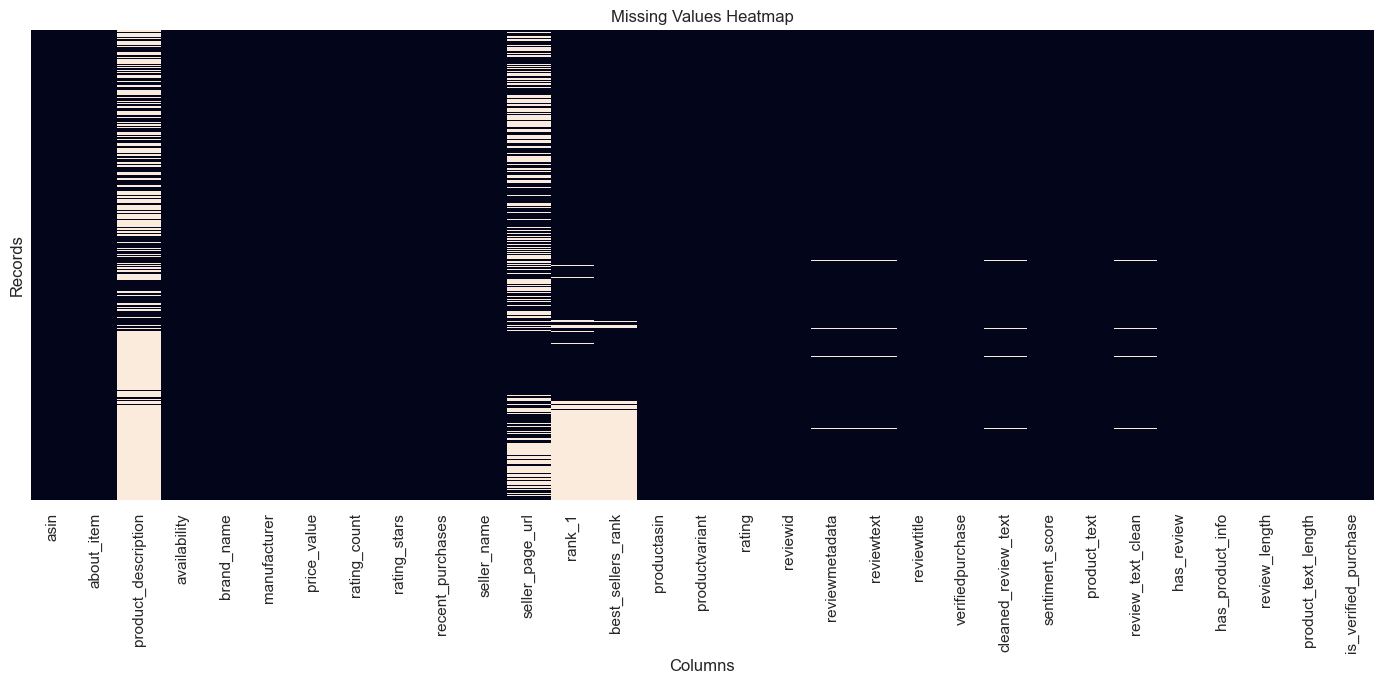

In [7]:
plt.figure(figsize=(14, 7))

# Heatmap missing values
sns.heatmap(
    df.isna(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Records")
plt.tight_layout()
plt.show()

## Kết luận phần 1

Dataset sau cleaning có thể được sử dụng cho EDA chuyên sâu nếu các cột chính như `seller_name`, `productasin`, `reviewid`, `rating`, `review_text_clean` và `sentiment_score` có mức độ đầy đủ chấp nhận được.

Với mục tiêu xây dựng Seller ESG Framework, dataset có giá trị vì kết nối được ba lớp thông tin quan trọng:

- Thông tin sản phẩm.
- Thông tin seller.
- Phản hồi khách hàng.

Tuy nhiên, các cột có missing cao cần được xem xét cẩn thận và không nên dùng làm chỉ báo chính nếu coverage quá thấp.

# PHẦN 2. PRODUCT ANALYSIS

Phần này phân tích đặc điểm sản phẩm thời trang trên Amazon.  
Các biến như giá, availability, rating và recent purchases có thể phản ánh đặc điểm thị trường, mức độ phổ biến sản phẩm và hành vi tiêu dùng.

Phần này chỉ khám phá dữ liệu, chưa xây dựng chỉ báo ESG.

In [9]:
display_section_title("PHẦN 2. PRODUCT ANALYSIS")

# Số lượng sản phẩm
if "asin" in df.columns:
    print("Number of unique products by asin:", df["asin"].nunique())

if "productasin" in df.columns:
    print("Number of unique products by productasin:", df["productasin"].nunique())

# Availability distribution
if "availability" in df.columns:
    print("\nProduct availability distribution:")
    display(df["availability"].value_counts(dropna=False).head(20))


PHẦN 2. PRODUCT ANALYSIS
Number of unique products by asin: 700
Number of unique products by productasin: 700

Product availability distribution:


availability
In Stock                                       5721
Only 1 left in stock - order soon.              115
In stock                                        103
unknown                                          99
Only 3 left in stock - order soon.               94
Currently unavailable.                           77
Only 2 left in stock - order soon.               48
Only 5 left in stock - order soon.               22
Available to ship in 1-2 days                    20
This item will be released on May 20, 2025.      10
Only 4 left in stock - order soon.                9
Temporarily out of stock.                         9
Name: count, dtype: int64

In [10]:
product_numeric_cols = [
    "price_value",
    "rating_stars",
    "rating_count",
    "recent_purchases",
    "rating"
]

product_summary = numeric_summary(df, product_numeric_cols)
display(product_summary)

,mean,median,std,min,max,count
price_value,34.1253,28.7928,22.9522,5.4573,174.9900,6327.0000
rating_stars,0.0000,0.0000,0.0000,0.0000,0.0000,6327.0000
rating_count,0.0000,0.0000,0.0000,0.0000,0.0000,6327.0000
recent_purchases,0.0000,0.0000,0.0000,0.0000,0.0000,6327.0000
rating,4.5337,5.0000,0.8554,1.0000,5.0000,6327.0000


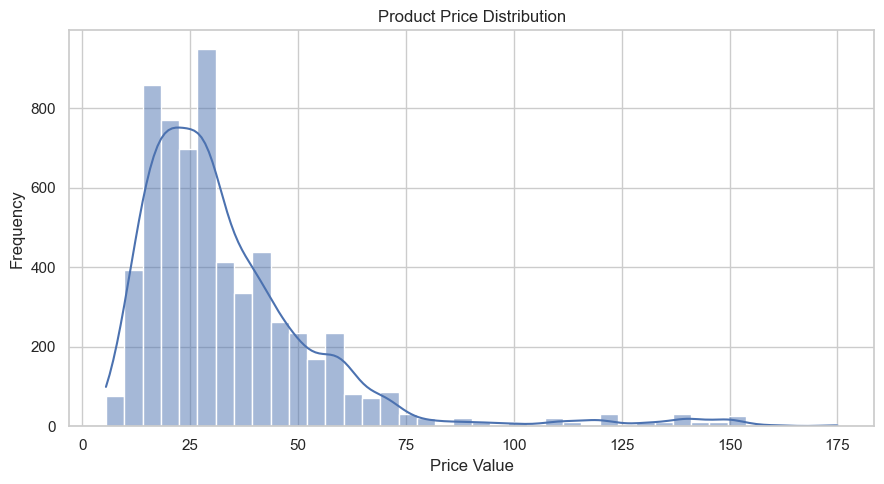

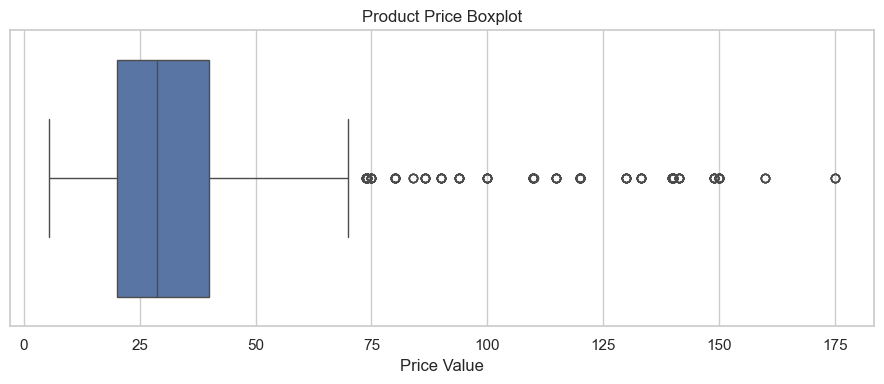

In [11]:
plot_histogram(
    df,
    column="price_value",
    title="Product Price Distribution",
    xlabel="Price Value",
    bins=40
)

plot_boxplot(
    df,
    column="price_value",
    title="Product Price Boxplot",
    xlabel="Price Value"
)

In [12]:
if "price_value" in df.columns:
    price_data = df["price_value"].dropna()

    q1 = price_data.quantile(0.25)
    q3 = price_data.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    price_outliers = df[
        (df["price_value"] < lower_bound) |
        (df["price_value"] > upper_bound)
    ]

    print("Price Q1:", q1)
    print("Price Q3:", q3)
    print("Price IQR:", iqr)
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    print("Number of price outliers:", price_outliers.shape[0])
    print(f"Outlier rate: {price_outliers.shape[0] / len(df) * 100:.2f}%")

Price Q1: 19.99
Price Q3: 40.0118
Price IQR: 20.021800000000002
Lower bound: -10.042700000000007
Upper bound: 70.0445
Number of price outliers: 263
Outlier rate: 4.16%


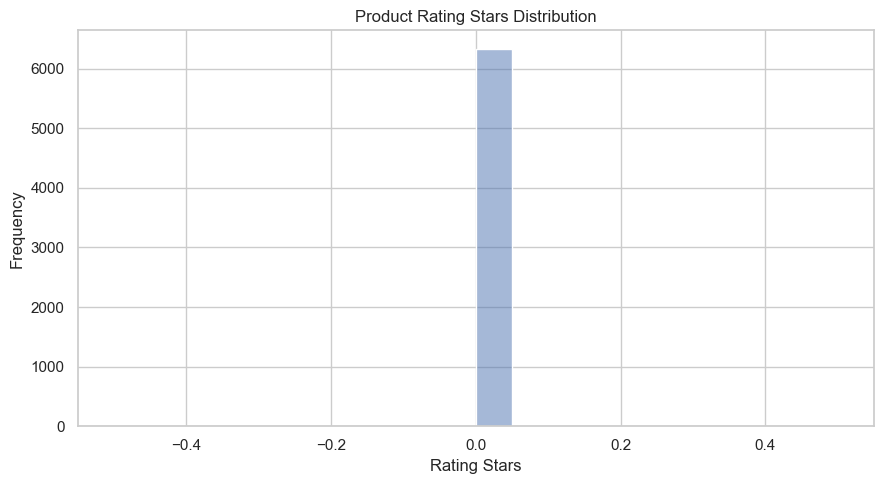

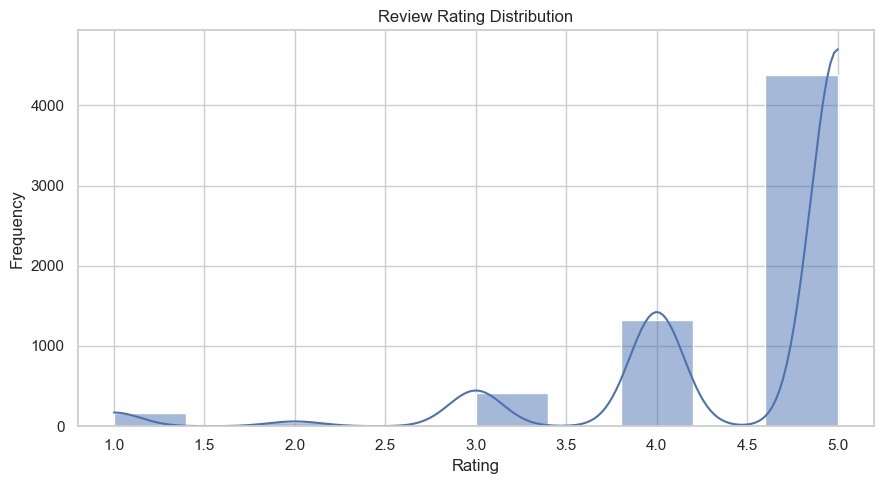

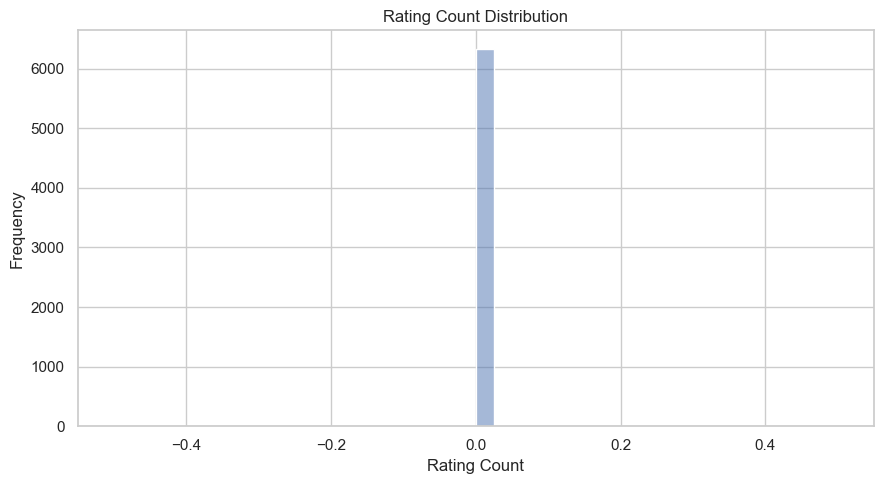

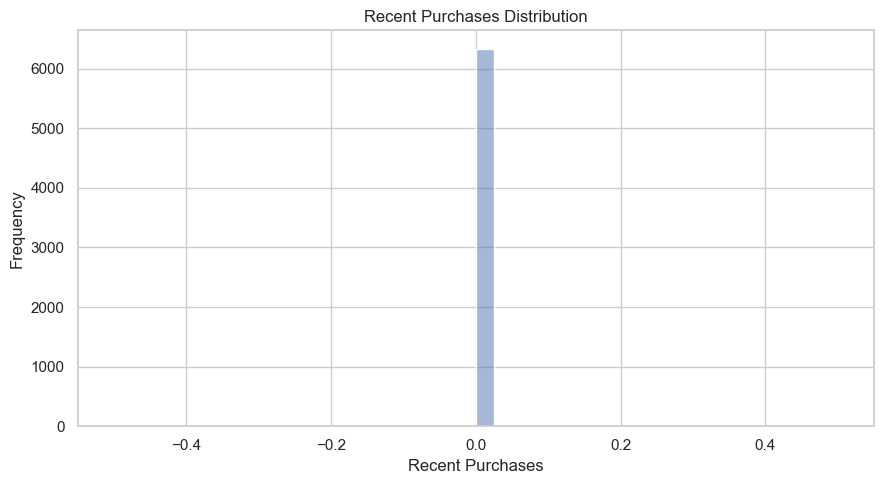

In [13]:
# Rating stars nếu có
plot_histogram(
    df,
    column="rating_stars",
    title="Product Rating Stars Distribution",
    xlabel="Rating Stars",
    bins=20
)

# Rating từ review nếu rating_stars không đầy đủ thì cột rating vẫn hữu ích
plot_histogram(
    df,
    column="rating",
    title="Review Rating Distribution",
    xlabel="Rating",
    bins=10
)

# Rating count distribution
plot_histogram(
    df,
    column="rating_count",
    title="Rating Count Distribution",
    xlabel="Rating Count",
    bins=40
)

# Recent purchases distribution
plot_histogram(
    df,
    column="recent_purchases",
    title="Recent Purchases Distribution",
    xlabel="Recent Purchases",
    bins=40
)

## Kết luận phần 2

Phân tích sản phẩm giúp nhận diện đặc điểm giá, mức độ phổ biến và chất lượng đánh giá của sản phẩm thời trang trên Amazon.

Nếu `price_value`, `rating`, `rating_count` hoặc `recent_purchases` có độ lệch lớn, điều này cho thấy thị trường có sự phân hóa giữa nhóm sản phẩm phổ thông và nhóm sản phẩm có sức mua hoặc độ nhận diện cao hơn.

Các biến sản phẩm có thể hỗ trợ bước xây dựng framework sau này, nhưng trong notebook này chỉ dừng ở mức khám phá dữ liệu.

# PHẦN 3. BRAND ANALYSIS

Brand analysis giúp khám phá mức độ tập trung thương hiệu và chất lượng phản hồi theo brand.

Trong bối cảnh thương mại điện tử, brand có thể ảnh hưởng đến niềm tin khách hàng, perceived quality và hành vi đánh giá.

In [14]:
display_section_title("PHẦN 3. BRAND ANALYSIS")

if "brand_name" in df.columns:
    print("Number of unique brands:", df["brand_name"].nunique())

    brand_product_count = (
        df.groupby("brand_name")["productasin"]
        .nunique()
        .sort_values(ascending=False)
    )

    print("\nTop brands by product count:")
    display(brand_product_count.head(20))
else:
    print("Không có cột brand_name.")


PHẦN 3. BRAND ANALYSIS
Number of unique brands: 278

Top brands by product count:


brand_name
Hanes Store                          34
Amazon Essentials Store              24
Under Armour Store                   20
Lee Store                            18
adidas Store                         18
POLO RALPH LAUREN Store              16
Dokotoo Store                        15
Skechers Store                       15
COOFANDY Store                       14
Simple Joys by Carter's Store        12
Levi's Store                         11
Wrangler Authentics Store            10
Gildan Store                         10
The Children's Place Store            9
Levi Strauss Signature Gold Store     9
KISAH Store                           9
DOCKERS Store                         8
Carhartt Store                        8
Brand: Gerber                         7
Real Essentials Store                 7
Name: productasin, dtype: int64

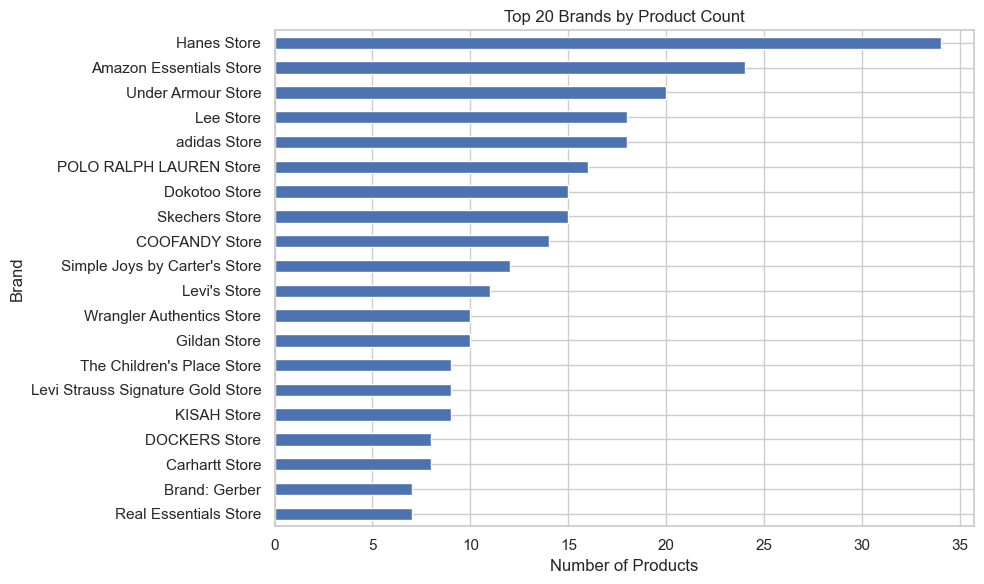

In [15]:
if "brand_name" in df.columns and "productasin" in df.columns:
    plot_top_bar(
        brand_product_count.head(20),
        title="Top 20 Brands by Product Count",
        xlabel="Number of Products",
        ylabel="Brand"
    )

In [16]:
if all(col in df.columns for col in ["brand_name", "rating", "reviewid"]):
    brand_stats = (
        df.groupby("brand_name")
        .agg(
            avg_rating=("rating", "mean"),
            review_count=("reviewid", "nunique"),
            product_count=("productasin", "nunique")
        )
        .reset_index()
    )

    # Chỉ xét brand có số review tối thiểu để tránh rating trung bình bị nhiễu
    brand_stats_filtered = brand_stats[brand_stats["review_count"] >= 5]

    top_brands_rating = (
        brand_stats_filtered
        .sort_values("avg_rating", ascending=False)
        .head(20)
    )

    top_brands_review = (
        brand_stats
        .sort_values("review_count", ascending=False)
        .head(20)
    )

    print("Top brands by average rating:")
    display(top_brands_rating)

    print("Top brands by review count:")
    display(top_brands_review)

Top brands by average rating:


,brand_name,avg_rating,review_count,product_count
129,Hudson Baby Store,4.9091,11,2
130,INNERSY Store,4.9000,10,1
173,Merrell Store,4.9000,10,1
71,CAMEL CROWN Store,4.9000,10,1
46,Brand: Onesies Brand,4.9000,20,2
81,Cole Haan Store,4.9000,10,1
82,Columbia Store,4.9000,20,2
91,ELETOP Store,4.9000,10,1
32,Brand: Handcraft,4.9000,10,1
27,Brand: Converse,4.9000,10,1


Top brands by review count:


,brand_name,avg_rating,review_count,product_count
122,Hanes Store,4.5629,318,34
12,Amazon Essentials Store,4.5256,234,24
255,Under Armour Store,4.7653,196,20
153,Lee Store,4.6818,176,18
273,adidas Store,4.6728,162,18
233,Skechers Store,4.5586,145,15
194,POLO RALPH LAUREN Store,4.6454,141,16
88,Dokotoo Store,4.4338,136,15
73,COOFANDY Store,4.4091,132,14
232,Simple Joys by Carter's Store,4.8661,112,12


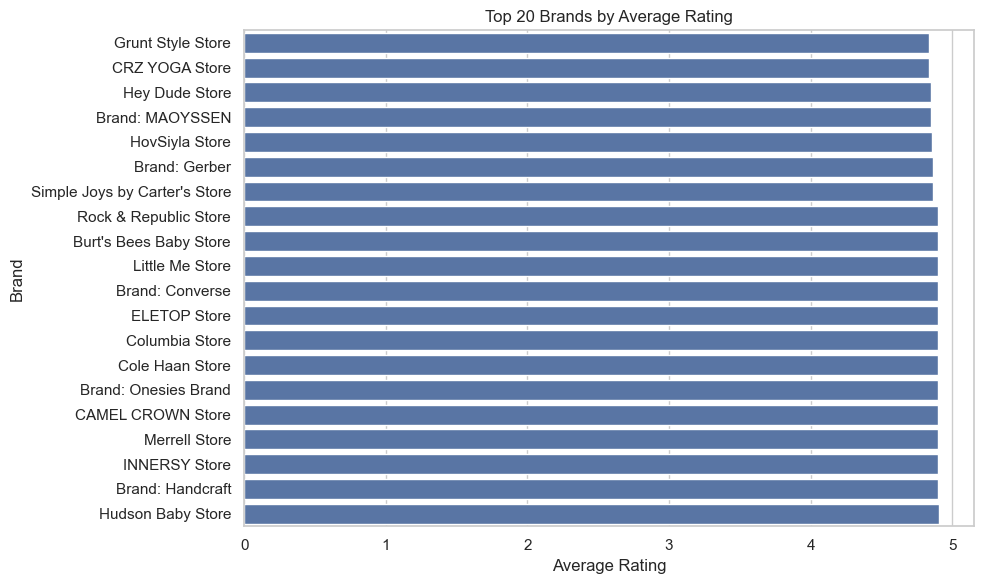

In [17]:
if "top_brands_rating" in globals() and not top_brands_rating.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=top_brands_rating.sort_values("avg_rating"),
        x="avg_rating",
        y="brand_name"
    )
    plt.title("Top 20 Brands by Average Rating")
    plt.xlabel("Average Rating")
    plt.ylabel("Brand")
    plt.tight_layout()
    plt.show()

## Kết luận phần 3

Brand analysis cho thấy mức độ tập trung của các thương hiệu trong dataset.  
Các brand có nhiều sản phẩm hoặc nhiều review có thể đóng vai trò quan trọng trong phân tích thị trường.

Average rating theo brand chỉ nên diễn giải khi brand có đủ số lượng review, vì các brand có quá ít review dễ tạo ra kết luận sai lệch.

# PHẦN 4. SELLER ANALYSIS

Seller là đơn vị phân tích trung tâm của đề tài.  
Phần này khám phá quy mô hoạt động của seller thông qua số sản phẩm, số review, rating trung bình và sentiment trung bình.

Các thống kê ở phần này giúp đánh giá khả năng xây dựng seller-level dataset cho ESG scoring ở notebook sau.

In [18]:
display_section_title("PHẦN 4. SELLER ANALYSIS")

if "seller_name" in df.columns:
    print("Number of unique sellers:", df["seller_name"].nunique())
else:
    print("Không có cột seller_name.")


PHẦN 4. SELLER ANALYSIS
Number of unique sellers: 261


In [19]:
if all(col in df.columns for col in ["seller_name", "productasin"]):
    seller_product_count = (
        df.groupby("seller_name")["productasin"]
        .nunique()
        .sort_values(ascending=False)
    )

    print("Top sellers by product count:")
    display(seller_product_count.head(20))

if all(col in df.columns for col in ["seller_name", "reviewid"]):
    seller_review_count = (
        df.groupby("seller_name")["reviewid"]
        .nunique()
        .sort_values(ascending=False)
    )

    print("Top sellers by review count:")
    display(seller_review_count.head(20))

Top sellers by product count:


seller_name
Amazon.com               271
unknown                   19
PAATM SHIVA               15
Dokotoo Flagship Shop     15
COOFANDY                   8
SuperiorBrands             7
ZITY®                      7
KISAHAPPARELS              7
Automet-US                 7
Real Essentials            7
PRETTYGARDEN               6
JMIERR                     5
TACVASEN                   5
COOFANDY Online            5
BOOJO Flagship Store       4
MAGCOMSEN                  4
Zappos                     4
Dp Fami                    4
MEROKEETY                  3
BMJL US                    3
Name: productasin, dtype: int64

Top sellers by review count:


seller_name
Amazon.com               2525
Dokotoo Flagship Shop     136
PAATM SHIVA               105
unknown                   105
COOFANDY                   72
SuperiorBrands             70
Automet-US                 65
Real Essentials            64
ZITY®                      61
PRETTYGARDEN               60
Dp Fami                    53
TACVASEN                   50
JMIERR                     50
COOFANDY Online            50
BOOJO Flagship Store       41
MAGCOMSEN                  40
KISAHAPPARELS              37
Zappos                     32
CRZ YOGA                   31
ZEAGOO                     30
Name: reviewid, dtype: int64

In [ ]:
# Seller rating and sentiment

seller_agg_dict = {}

if "rating" in df.columns:
    seller_agg_dict["avg_rating"] = ("rating", "mean")

if "sentiment_score" in df.columns:
    seller_agg_dict["avg_sentiment"] = ("sentiment_score", "mean")

if "reviewid" in df.columns:
    seller_agg_dict["review_count"] = ("reviewid", "nunique")

if "productasin" in df.columns:
    seller_agg_dict["product_count"] = ("productasin", "nunique")

if "seller_name" in df.columns and seller_agg_dict:
    seller_stats = (
        df.groupby("seller_name")
        .agg(**seller_agg_dict)
        .reset_index()
    )

    display(seller_stats.head())

,seller_name,avg_rating,avg_sentiment,review_count,product_count
0,101Dealz,4.1667,0.2905,30,3
1,123(EXOPRT WAREHOUSE),4.7500,0.2356,4,1
2,24 Caret,2.9000,0.0959,10,1
3,"33,000ft outdoor",4.8000,0.3141,10,1
4,5Mayi Official,4.4000,0.2317,10,1


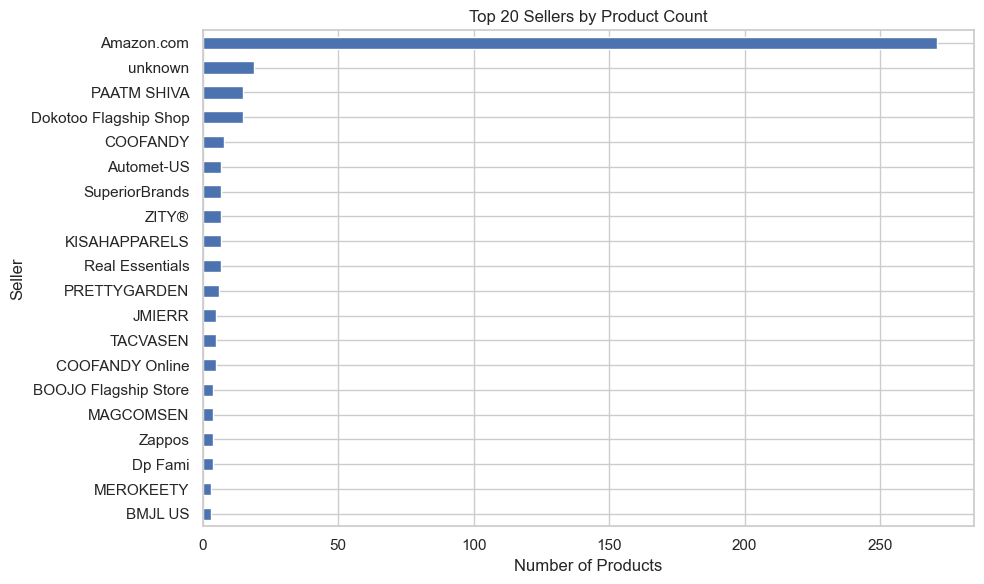

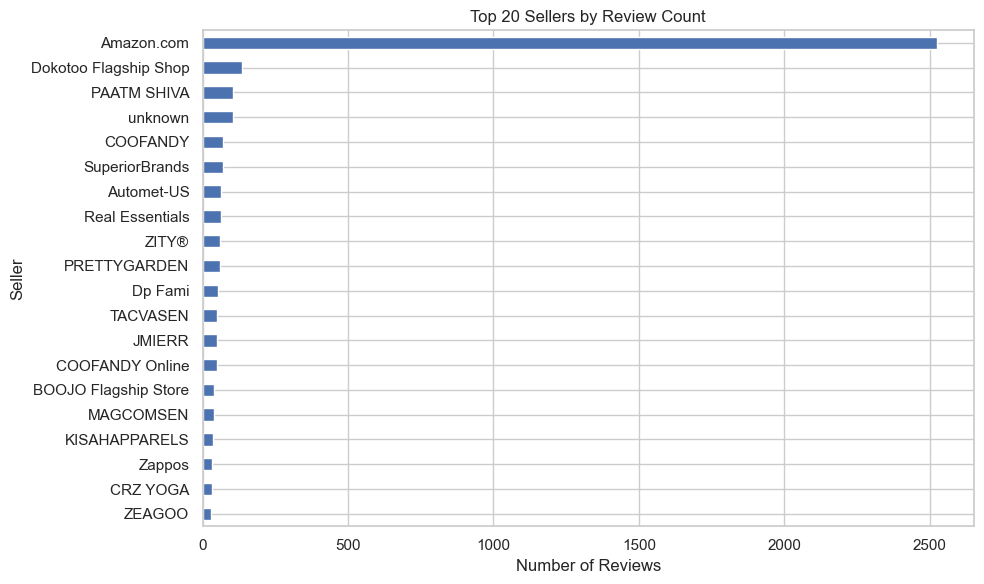

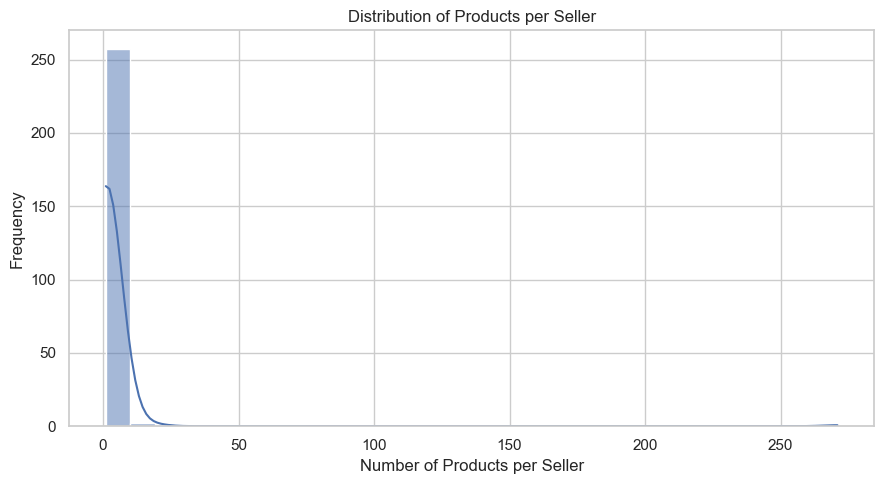

In [21]:
# Seller visualizations

if "seller_product_count" in globals():
    plot_top_bar(
        seller_product_count.head(20),
        title="Top 20 Sellers by Product Count",
        xlabel="Number of Products",
        ylabel="Seller"
    )

if "seller_review_count" in globals():
    plot_top_bar(
        seller_review_count.head(20),
        title="Top 20 Sellers by Review Count",
        xlabel="Number of Reviews",
        ylabel="Seller"
    )

if "seller_product_count" in globals():
    plt.figure(figsize=(9, 5))
    sns.histplot(seller_product_count, bins=30, kde=True)
    plt.title("Distribution of Products per Seller")
    plt.xlabel("Number of Products per Seller")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## Kết luận phần 4

Seller analysis cho thấy mức độ tập trung hoạt động giữa các nhà bán hàng.  
Nếu một số seller có số lượng sản phẩm hoặc review vượt trội, dataset có thể bị ảnh hưởng bởi seller lớn.

Các biến như `seller_product_count`, `seller_review_count`, `avg_rating` và `avg_sentiment` có tiềm năng hỗ trợ xây dựng seller-level dataset ở bước sau.

# PHẦN 5. REVIEW ANALYSIS

Review analysis giúp hiểu hành vi phản hồi của khách hàng.  
Trong nghiên cứu ESG trên thương mại điện tử, review có thể cung cấp tín hiệu gián tiếp về chất lượng sản phẩm, độ tin cậy, trải nghiệm khách hàng và mức độ hài lòng.

Phần này không thực hiện ESG keyword analysis.

In [22]:
# Create review length variables

display_section_title("PHẦN 5. REVIEW ANALYSIS")

# Tạo review_length từ review_text_clean nếu có
if "review_text_clean" in df.columns:
    df["review_length"] = df["review_text_clean"].fillna("").astype(str).str.len()
elif "reviewtext" in df.columns:
    df["review_length"] = df["reviewtext"].fillna("").astype(str).str.len()
else:
    df["review_length"] = 0

# Tạo review_title_length
if "reviewtitle" in df.columns:
    df["review_title_length"] = df["reviewtitle"].fillna("").astype(str).str.len()
else:
    df["review_title_length"] = 0

display(df[["review_length", "review_title_length"]].describe())


PHẦN 5. REVIEW ANALYSIS


,review_length,review_title_length
count,6327.0000,6327.0000
mean,206.7493,22.6675
std,318.0807,15.5565
min,0.0000,0.0000
25%,54.0000,12.0000
50%,113.0000,19.0000
75%,231.5000,29.0000
max,9498.0000,100.0000


Rating distribution:


rating
1.0000     158
2.0000      55
3.0000     414
4.0000    1325
5.0000    4375
Name: count, dtype: int64

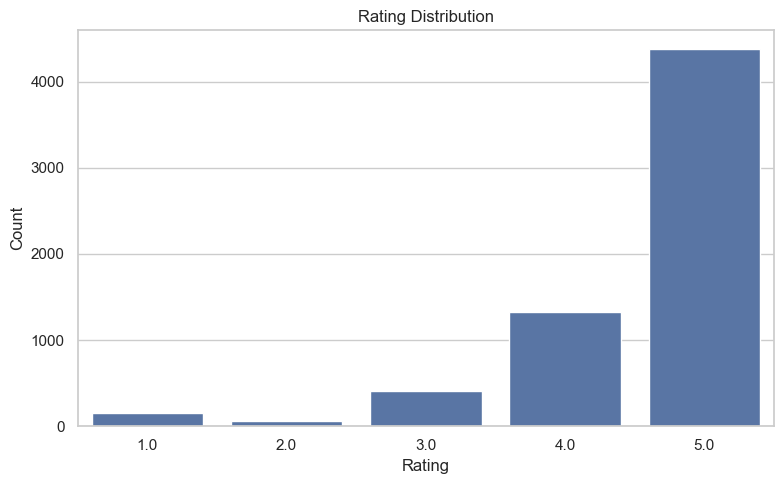

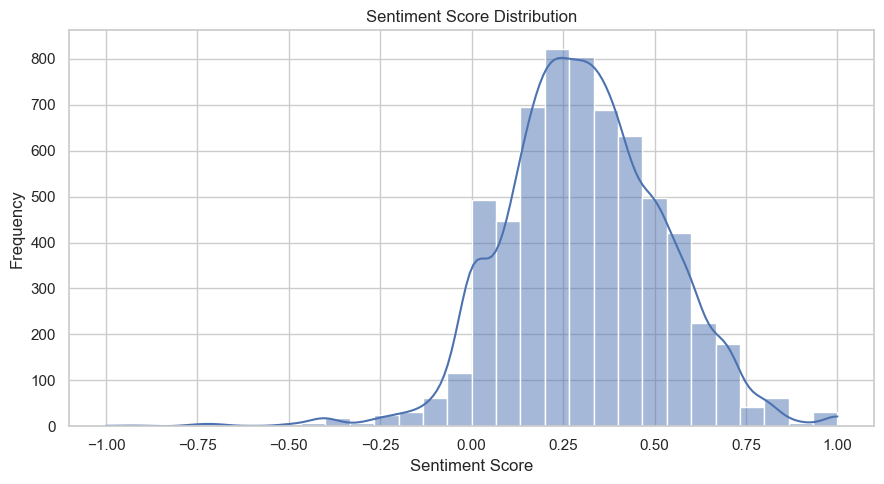

In [23]:
# Rating and sentiment distribution

if "rating" in df.columns:
    print("Rating distribution:")
    display(df["rating"].value_counts(dropna=False).sort_index())

    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x="rating")
    plt.title("Rating Distribution")
    plt.xlabel("Rating")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

plot_histogram(
    df,
    column="sentiment_score",
    title="Sentiment Score Distribution",
    xlabel="Sentiment Score",
    bins=30
)

Bỏ qua helpfulvote: cột không tồn tại.
Verified purchase distribution:


verifiedpurchase
True     6167
False     160
Name: count, dtype: int64

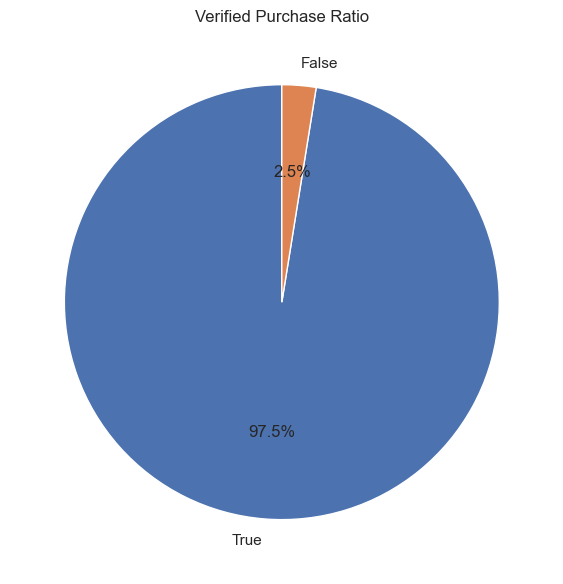

In [24]:
# Helpful vote and verified purchase

plot_histogram(
    df,
    column="helpfulvote",
    title="Helpful Vote Distribution",
    xlabel="Helpful Vote",
    bins=40
)

if "verifiedpurchase" in df.columns:
    verified_counts = df["verifiedpurchase"].value_counts(dropna=False)

    print("Verified purchase distribution:")
    display(verified_counts)

    plt.figure(figsize=(6, 6))
    verified_counts.plot(kind="pie", autopct="%1.1f%%", startangle=90)
    plt.title("Verified Purchase Ratio")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

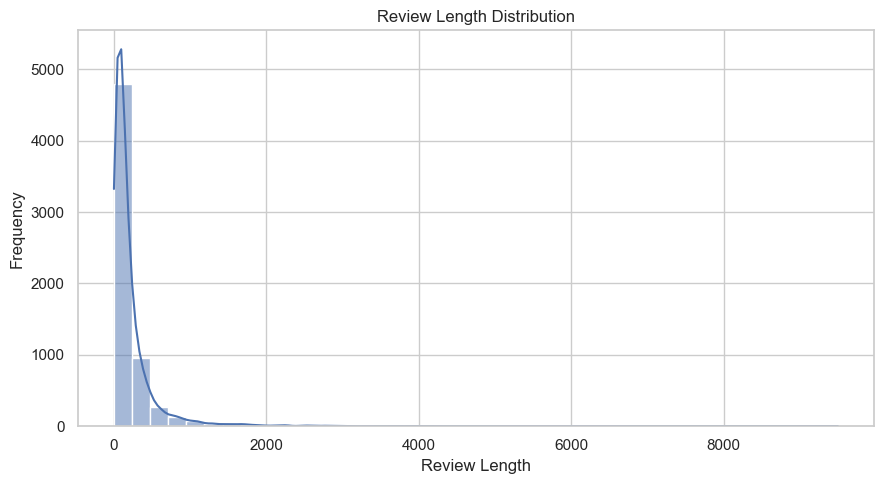

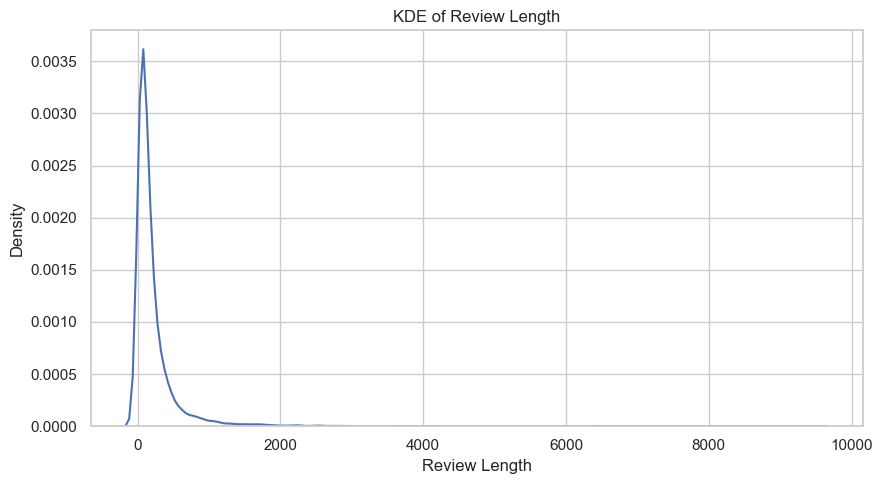

In [25]:
# Review length visualizations

plot_histogram(
    df,
    column="review_length",
    title="Review Length Distribution",
    xlabel="Review Length",
    bins=40
)

plt.figure(figsize=(9, 5))
sns.kdeplot(df["review_length"].dropna())
plt.title("KDE of Review Length")
plt.xlabel("Review Length")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

## Kết luận phần 5

Review analysis cho thấy đặc điểm phản hồi của khách hàng thông qua rating, sentiment, helpful vote, verified purchase và độ dài review.

Nếu rating và sentiment có xu hướng tích cực mạnh, dataset có thể bị lệch về nhóm khách hàng hài lòng.  
Helpful vote và verified purchase là các biến quan trọng để đánh giá độ tin cậy và mức độ hữu ích của review.

# PHẦN 6. CUSTOMER SATISFACTION ANALYSIS

Phần này khám phá mối quan hệ giữa rating, sentiment, helpful vote và độ dài review.

Rating thể hiện đánh giá định lượng, trong khi sentiment score phản ánh cảm xúc trong nội dung review.  
Nếu hai biến này có tương quan cao, sentiment có thể được xem là tín hiệu bổ trợ cho customer satisfaction.

Các phân tích sử dụng:

- Pearson correlation.
- Spearman correlation.
- Correlation heatmap.
- Scatterplots.
- Pairplots.

In [27]:
# Correlation variables

display_section_title("PHẦN 6. CUSTOMER SATISFACTION ANALYSIS")

satisfaction_cols = [
    "rating",
    "sentiment_score",
    "helpfulvote",
    "review_length"
]

existing_satisfaction_cols = [
    col for col in satisfaction_cols
    if col in df.columns
]

satisfaction_df = df[existing_satisfaction_cols].copy()

# Chuyển các cột về numeric để tính tương quan
for col in existing_satisfaction_cols:
    satisfaction_df[col] = pd.to_numeric(satisfaction_df[col], errors="coerce")

display(satisfaction_df.describe())


PHẦN 6. CUSTOMER SATISFACTION ANALYSIS


,rating,sentiment_score,review_length
count,6327.0000,6327.0000,6327.0000
mean,4.5337,0.3075,206.7493
std,0.8554,0.2180,318.0807
min,1.0000,-1.0000,0.0000
25%,4.0000,0.1686,54.0000
50%,5.0000,0.3000,113.0000
75%,5.0000,0.4500,231.5000
max,5.0000,1.0000,9498.0000


In [28]:
# Pearson and Spearman correlation

if len(existing_satisfaction_cols) >= 2:
    pearson_corr = satisfaction_df.corr(method="pearson")
    spearman_corr = satisfaction_df.corr(method="spearman")

    print("Pearson correlation:")
    display(pearson_corr)

    print("Spearman correlation:")
    display(spearman_corr)

Pearson correlation:


,rating,sentiment_score,review_length
rating,1.0000,0.3601,0.0013
sentiment_score,0.3601,1.0000,-0.2100
review_length,0.0013,-0.2100,1.0000


Spearman correlation:


,rating,sentiment_score,review_length
rating,1.0000,0.3243,-0.0325
sentiment_score,0.3243,1.0000,-0.3566
review_length,-0.0325,-0.3566,1.0000


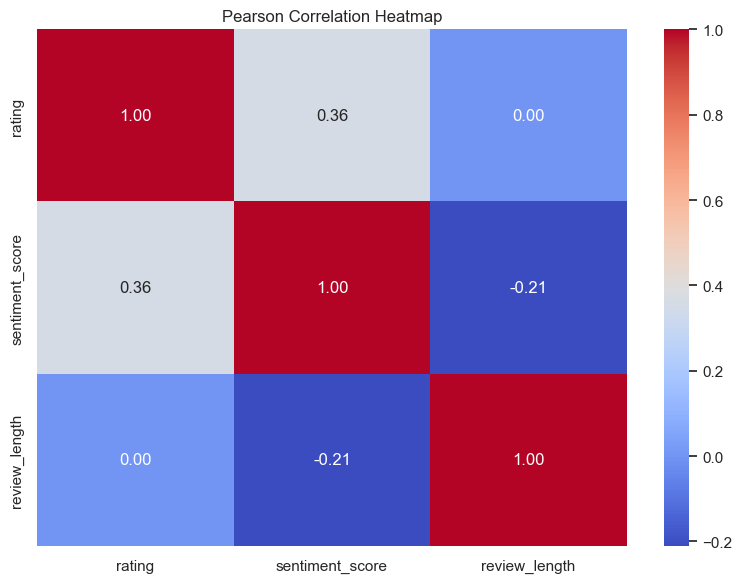

In [ ]:
# Correlation heatmap

if len(existing_satisfaction_cols) >= 2:
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        pearson_corr,
        annot=True,
        cmap="coolwarm",
        fmt=".2f"
    )
    plt.title("Pearson Correlation Heatmap")
    plt.tight_layout()
    plt.show()

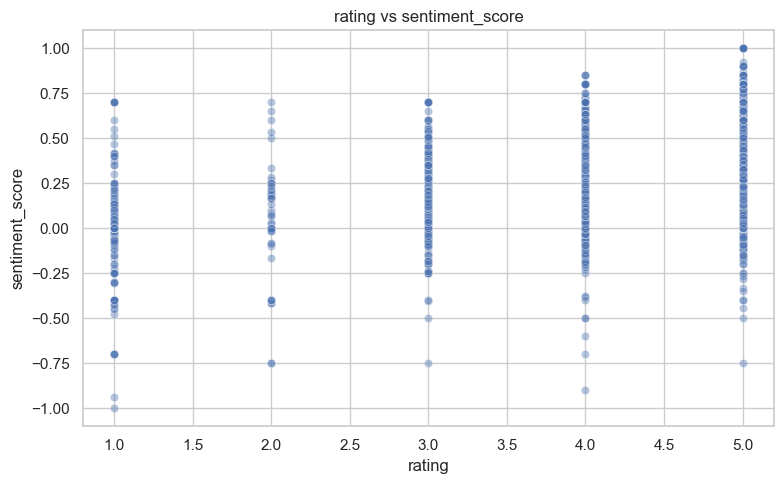

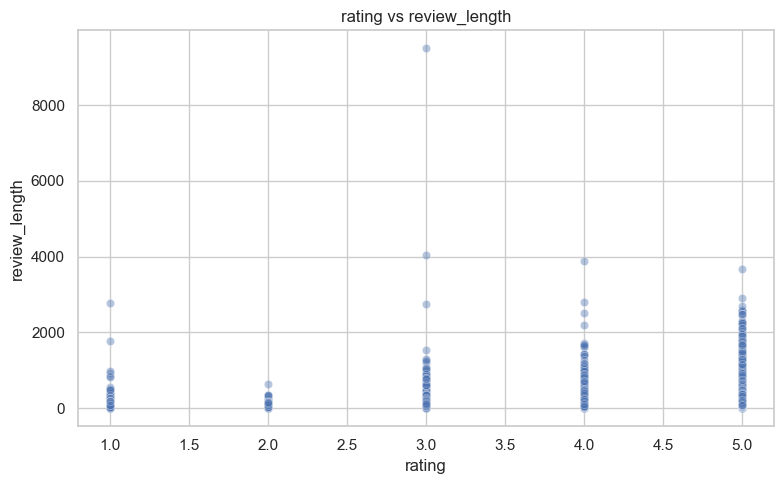

In [ ]:
# Scatterplots

scatter_pairs = [
    ("rating", "sentiment_score"),
    ("rating", "helpfulvote"),
    ("rating", "review_length"),
    ("sentiment_score", "helpfulvote")
]

for x_col, y_col in scatter_pairs:
    if x_col in df.columns and y_col in df.columns:
        plt.figure(figsize=(8, 5))
        sns.scatterplot(
            data=df,
            x=x_col,
            y=y_col,
            alpha=0.4
        )
        plt.title(f"{x_col} vs {y_col}")
        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.tight_layout()
        plt.show()

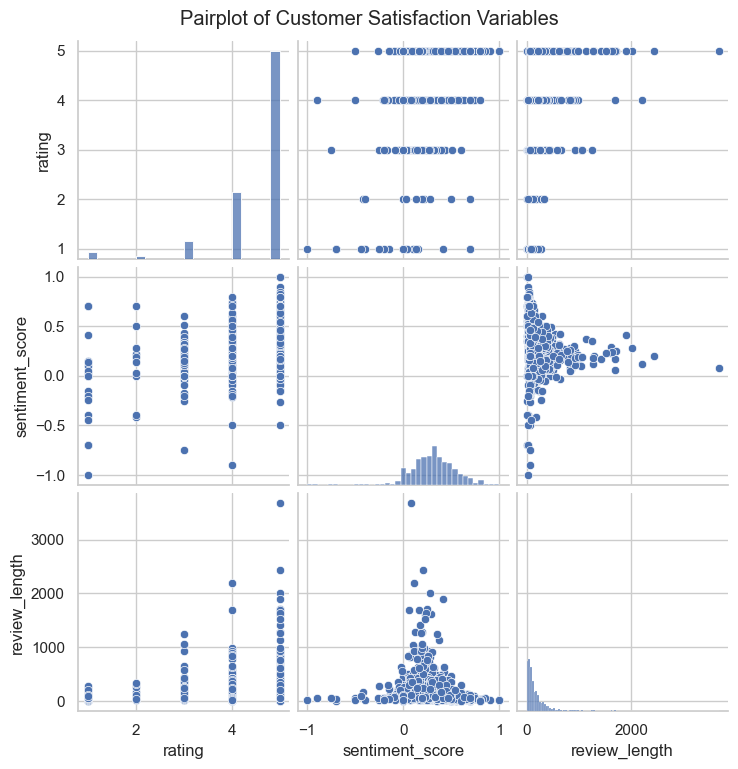

In [31]:
# Pairplot

if len(existing_satisfaction_cols) >= 2:
    sample_pairplot_df = satisfaction_df.dropna().sample(
        n=min(1000, satisfaction_df.dropna().shape[0]),
        random_state=42
    )

    sns.pairplot(sample_pairplot_df)
    plt.suptitle("Pairplot of Customer Satisfaction Variables", y=1.02)
    plt.show()

## Kết luận phần 6

Nếu rating và sentiment score có tương quan dương, điều này cho thấy đánh giá sao và cảm xúc trong nội dung review có sự nhất quán.

Các biến như rating, sentiment score, helpful vote và review length có thể cung cấp tín hiệu liên quan đến customer satisfaction.  
Trong bối cảnh ESG, nhóm biến này có thể hỗ trợ khía cạnh Social, đặc biệt ở góc độ trải nghiệm khách hàng và niềm tin người tiêu dùng.

# PHẦN 7. VERIFIED PURCHASE ANALYSIS

Verified purchase phản ánh review đến từ khách hàng đã xác minh mua hàng.  
Đây là yếu tố quan trọng khi đánh giá độ tin cậy của phản hồi khách hàng.

Phần này so sánh verified và non-verified reviews theo:

- Rating.
- Sentiment.
- Helpful votes.

In [32]:
# Normalize verified purchase status

display_section_title("PHẦN 7. VERIFIED PURCHASE ANALYSIS")

if "verifiedpurchase" in df.columns:
    df["verified_status"] = (
        df["verifiedpurchase"]
        .astype(str)
        .str.lower()
        .str.strip()
    )

    df["verified_status"] = np.where(
        df["verified_status"].isin(["true", "yes", "1", "verified purchase"]),
        "verified",
        "non_verified"
    )

    display(df["verified_status"].value_counts())
else:
    print("Không có cột verifiedpurchase.")


PHẦN 7. VERIFIED PURCHASE ANALYSIS


verified_status
verified        6167
non_verified     160
Name: count, dtype: int64

In [33]:
# Group comparison by verified status

comparison_cols = [
    "rating",
    "sentiment_score",
    "helpfulvote"
]

existing_comparison_cols = [
    col for col in comparison_cols
    if col in df.columns
]

if "verified_status" in df.columns and existing_comparison_cols:
    verified_summary = (
        df.groupby("verified_status")[existing_comparison_cols]
        .agg(["mean", "median", "std", "count"])
    )

    display(verified_summary)

rating                     sentiment_score                    
                  mean median    std count            mean median    std count
verified_status                                                               
non_verified    4.4500 5.0000 0.7673   160          0.2417 0.2457 0.1626   160
verified        4.5359 5.0000 0.8575  6167          0.3093 0.3031 0.2190  6167

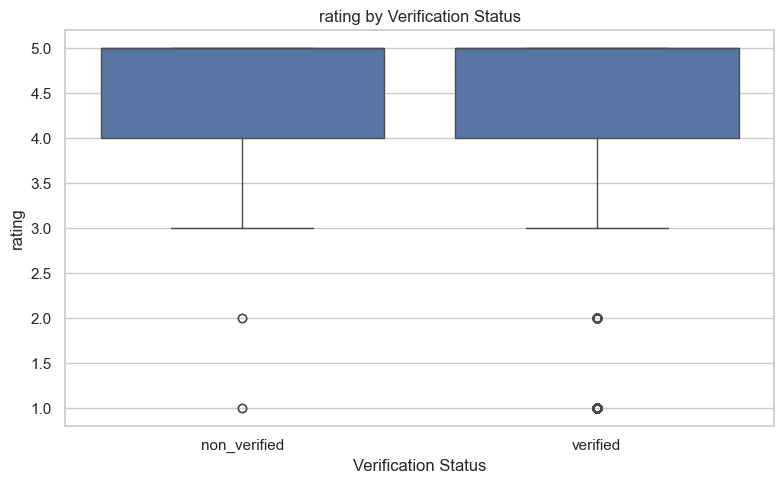

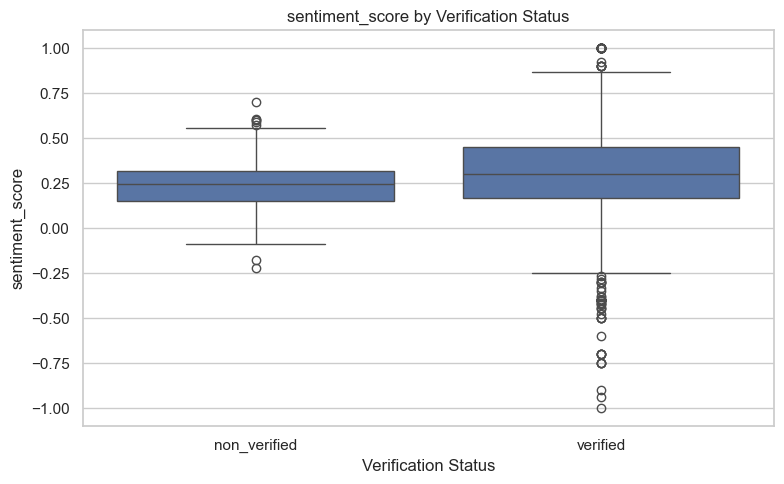

In [34]:
# Boxplots by verified status

if "verified_status" in df.columns:
    for col in existing_comparison_cols:
        plt.figure(figsize=(8, 5))
        sns.boxplot(
            data=df,
            x="verified_status",
            y=col
        )
        plt.title(f"{col} by Verification Status")
        plt.xlabel("Verification Status")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()

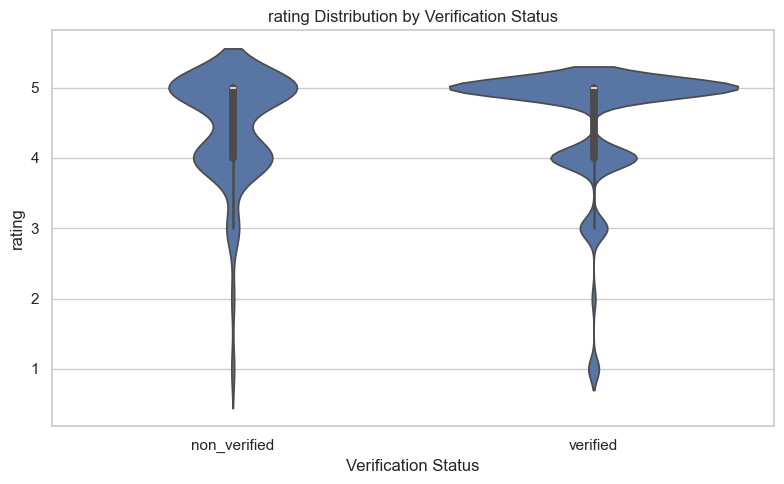

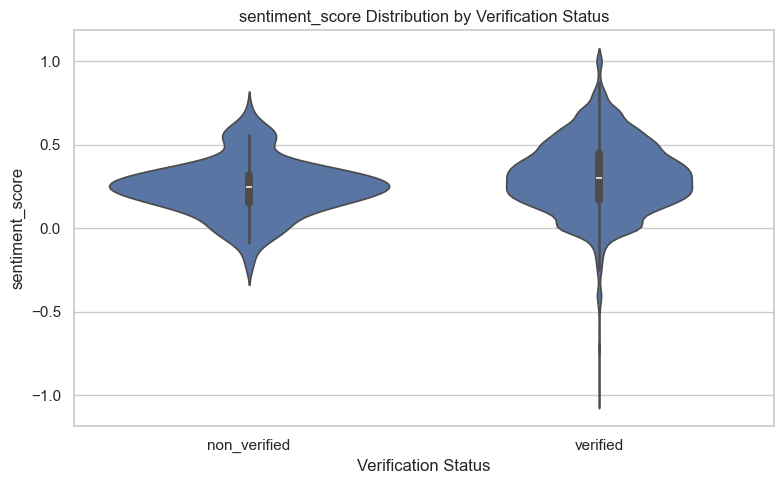

In [35]:
# Violin plots by verified status

if "verified_status" in df.columns:
    for col in existing_comparison_cols:
        plt.figure(figsize=(8, 5))
        sns.violinplot(
            data=df,
            x="verified_status",
            y=col
        )
        plt.title(f"{col} Distribution by Verification Status")
        plt.xlabel("Verification Status")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()

## Kết luận phần 7

Verified purchase có thể được xem là tín hiệu giúp đánh giá độ tin cậy của review.

Nếu verified reviews có rating hoặc sentiment khác biệt đáng kể so với non-verified reviews, trạng thái xác minh mua hàng có thể đóng vai trò quan trọng trong việc đánh giá Consumer Trust.

# PHẦN 8. TEXT ANALYSIS

Phần này khám phá đặc điểm nội dung review ở mức tổng quát.

Các phân tích gồm:

- Most frequent words.
- Most frequent bigrams.
- Most frequent trigrams.
- Positive reviews.
- Negative reviews.
- Word Cloud.

Lưu ý: phần này **không thực hiện ESG keyword analysis**.

In [36]:
# Prepare review text

display_section_title("PHẦN 8. TEXT ANALYSIS")

# Chọn cột text phù hợp
if "review_text_clean" in df.columns:
    review_text_col = "review_text_clean"
elif "reviewtext" in df.columns:
    review_text_col = "reviewtext"
else:
    review_text_col = None

print("Review text column:", review_text_col)

# Stopwords cơ bản tiếng Anh
basic_stopwords = set([
    "the", "a", "an", "and", "or", "to", "of", "in", "on", "for", "with",
    "is", "are", "was", "were", "it", "this", "that", "these", "those",
    "i", "you", "he", "she", "they", "we", "my", "your", "our", "their",
    "very", "so", "too", "as", "at", "by", "from", "be", "been", "have",
    "has", "had", "do", "does", "did", "but", "not", "no", "yes"
])


PHẦN 8. TEXT ANALYSIS
Review text column: review_text_clean


In [37]:
# Tokenize text

def tokenize_text(text):
    """
    Tách text thành danh sách token.
    Chỉ giữ chữ cái tiếng Anh và loại stopwords cơ bản.
    """
    if pd.isna(text):
        return []

    text = str(text).lower()
    tokens = re.findall(r"\b[a-z]{2,}\b", text)

    tokens = [
        token for token in tokens
        if token not in basic_stopwords
    ]

    return tokens


if review_text_col:
    df["tokens"] = df[review_text_col].apply(tokenize_text)

    all_tokens = list(chain.from_iterable(df["tokens"]))
    print("Total tokens:", len(all_tokens))
    print("Unique tokens:", len(set(all_tokens)))
else:
    print("Không có cột review text để phân tích.")

Total tokens: 198957
Unique tokens: 12711


,word,count
0,fit,3981
1,great,2463
2,size,2347
3,comfortable,2099
4,good,2071
5,like,2001
6,wear,1822
7,shirt,1787
8,quality,1722
9,color,1694


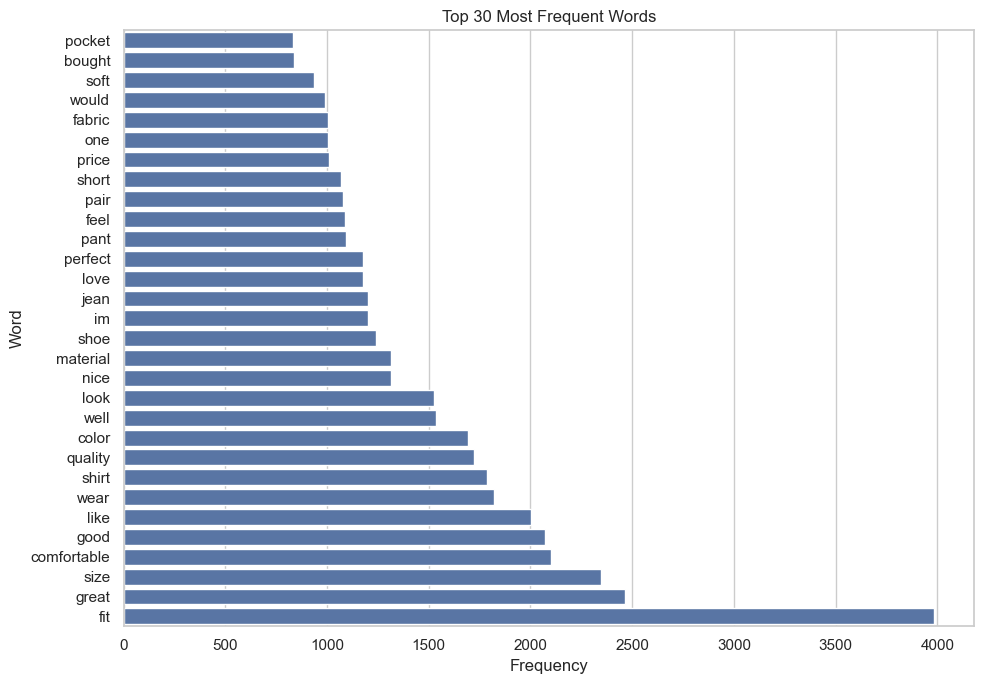

In [38]:
# Most frequent words

if review_text_col:
    word_freq = Counter(all_tokens)
    top_words = pd.DataFrame(
        word_freq.most_common(30),
        columns=["word", "count"]
    )

    display(top_words)

    plt.figure(figsize=(10, 7))
    sns.barplot(
        data=top_words.sort_values("count"),
        x="count",
        y="word"
    )
    plt.title("Top 30 Most Frequent Words")
    plt.xlabel("Frequency")
    plt.ylabel("Word")
    plt.tight_layout()
    plt.show()

In [39]:
# Most frequent bigrams and trigrams

def get_ngrams(tokens, n):
    """
    Tạo n-grams từ danh sách tokens.
    """
    return list(zip(*[tokens[i:] for i in range(n)]))


if review_text_col:
    all_bigrams = []
    all_trigrams = []

    for tokens in df["tokens"]:
        all_bigrams.extend(get_ngrams(tokens, 2))
        all_trigrams.extend(get_ngrams(tokens, 3))

    bigram_freq = Counter(all_bigrams)
    trigram_freq = Counter(all_trigrams)

    top_bigrams = pd.DataFrame(
        [(" ".join(k), v) for k, v in bigram_freq.most_common(20)],
        columns=["bigram", "count"]
    )

    top_trigrams = pd.DataFrame(
        [(" ".join(k), v) for k, v in trigram_freq.most_common(20)],
        columns=["trigram", "count"]
    )

    print("Top bigrams:")
    display(top_bigrams)

    print("Top trigrams:")
    display(top_trigrams)

Top bigrams:


,bigram,count
0,true size,530
1,fit well,344
2,good quality,336
3,fit perfectly,268
4,fit great,254
5,highly recommend,244
6,look great,243
7,well made,211
8,look good,200
9,feel like,191


Top trigrams:


,trigram,count
0,fit true size,168
1,highly recommend anyone,31
2,recommend anyone looking,31
3,last long time,31
4,run true size,30
5,great value money,29
6,fit well comfortable,28
7,size fit perfectly,28
8,good value money,28
9,well multiple wash,27


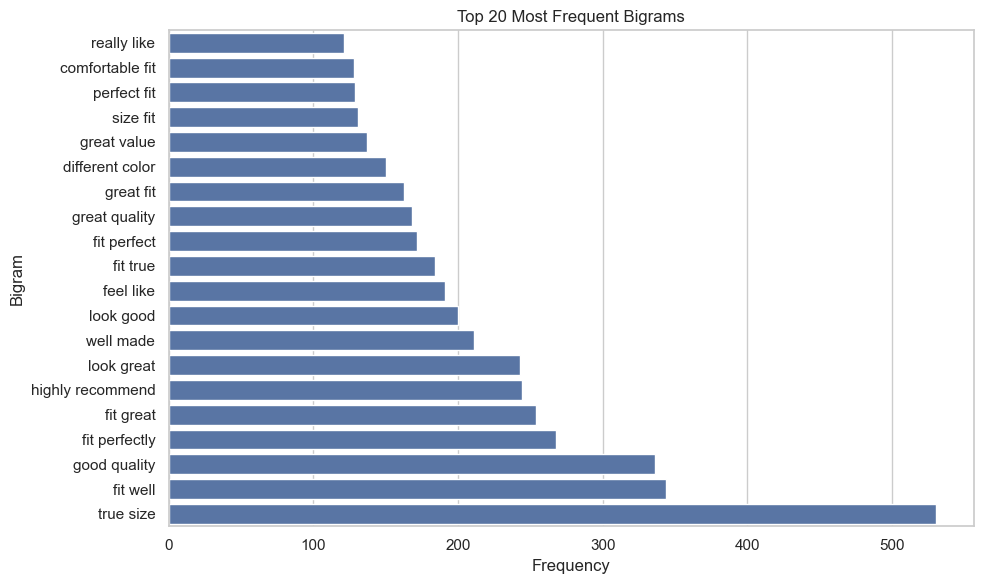

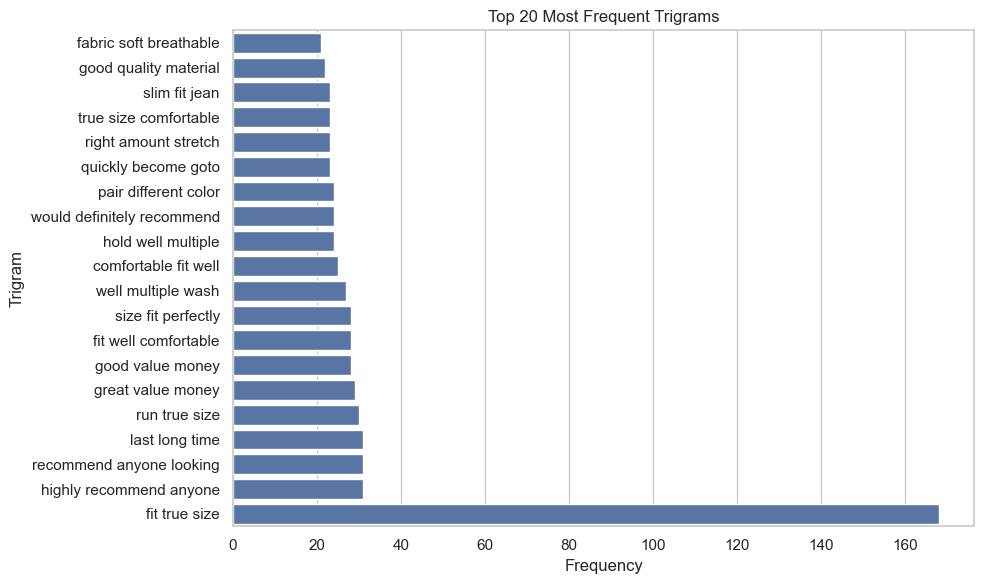

In [40]:
# Bigram and trigram visualizations

if review_text_col and not top_bigrams.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=top_bigrams.sort_values("count"),
        x="count",
        y="bigram"
    )
    plt.title("Top 20 Most Frequent Bigrams")
    plt.xlabel("Frequency")
    plt.ylabel("Bigram")
    plt.tight_layout()
    plt.show()

if review_text_col and not top_trigrams.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=top_trigrams.sort_values("count"),
        x="count",
        y="trigram"
    )
    plt.title("Top 20 Most Frequent Trigrams")
    plt.xlabel("Frequency")
    plt.ylabel("Trigram")
    plt.tight_layout()
    plt.show()

In [41]:
# Positive and negative reviews preview

if review_text_col and "rating" in df.columns:
    positive_reviews = df[df["rating"] >= 4][[review_text_col, "rating"]].head(10)
    negative_reviews = df[df["rating"] <= 2][[review_text_col, "rating"]].head(10)

    print("Positive reviews sample:")
    display(positive_reviews)

    print("Negative reviews sample:")
    display(negative_reviews)

Positive reviews sample:


,review_text_clean,rating
0,coofandy men polo shirt fantastic blend style ...,5.0000
1,love look good fit well comfortable breathable...,5.0000
2,expectation low good could shirt sell one mist...,4.0000
3,pack multicolor shirt really brainer wear type...,5.0000
4,three polo shirt satisfied quality material go...,5.0000
5,zity pack polo shirt good value shirt quality ...,5.0000
6,looking good could shave stroke golf game men ...,5.0000
7,wear xl year fit snug top polo seem snug top c...,5.0000
8,love shirt well made durable fit perfectly com...,5.0000
9,gave star button difficult negotiate otherwise...,4.0000


Negative reviews sample:


,review_text_clean,rating
124,mad product listed men youth waste money lied ...,1.0000
128,say men top product actually boy size ugh didn...,1.0000
165,really poor quality really thin see,1.0000
166,materialquality thin cheap,2.0000
173,sizing correct shirt market xl really large,1.0000
177,thought pack way priced last polo shirt bought...,1.0000
193,disappointed product amazon bought polo ralph ...,1.0000
276,returning poor quality fabric doesnt look nice...,1.0000
281,top picture appears beautiful good quality pur...,1.0000
286,shirt color shown sleeve like regular dress sh...,2.0000


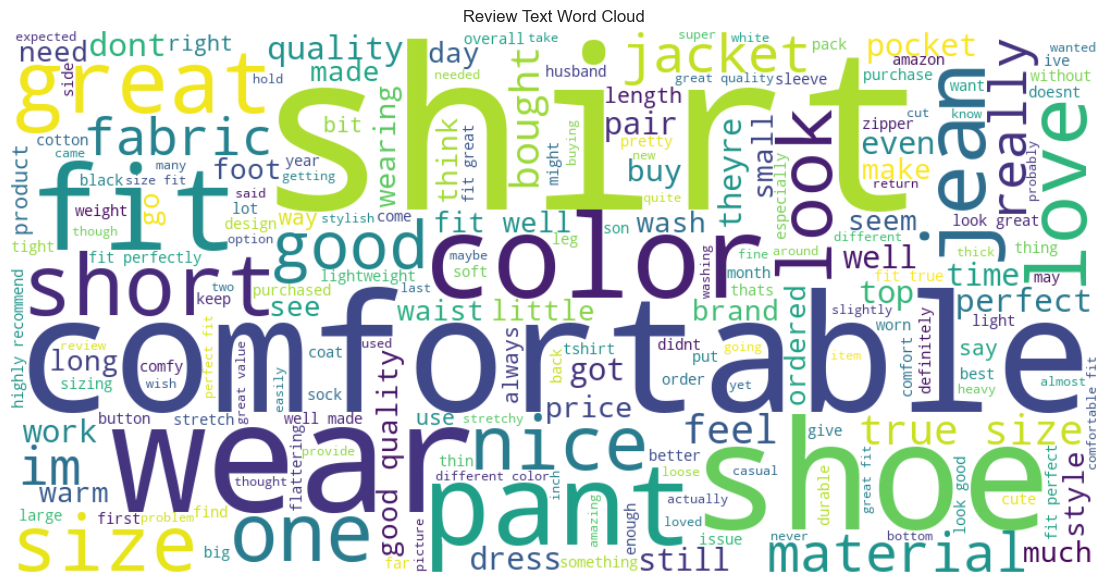

In [44]:
# Word cloud

if review_text_col and WORDCLOUD_AVAILABLE:
    text_for_wordcloud = " ".join(all_tokens)

    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color="white"
    ).generate(text_for_wordcloud)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud.to_image(), interpolation="bilinear")
    plt.axis("off")
    plt.title("Review Text Word Cloud")
    plt.tight_layout()
    plt.show()
else:
    print("Không thể tạo Word Cloud vì thiếu wordcloud hoặc không có text.")

## Kết luận phần 8

Text analysis cho thấy các chủ đề và từ ngữ phổ biến trong review khách hàng ở mức tổng quát.

Các kết quả này hữu ích để hiểu ngôn ngữ khách hàng sử dụng khi đánh giá sản phẩm thời trang.  
Notebook này không phân tích ESG keyword, do đó kết quả chỉ phục vụ khám phá nội dung review ban đầu.

# PHẦN 9. SELLER-LEVEL PREVIEW

Phần này kiểm tra khả năng chuyển dataset từ cấp review/product sang cấp seller.

Đây chưa phải Feature Engineering chính thức, mà chỉ là bước preview để đánh giá dataset có đủ điều kiện tạo seller-level dataset hay không.

Các chỉ số aggregate gồm:

- Average rating.
- Average sentiment.
- Average helpful vote.
- Verified purchase ratio.
- Review count.
- Product count.

In [45]:
# Seller-level aggregation preview

display_section_title("PHẦN 9. SELLER-LEVEL PREVIEW")

if "seller_name" in df.columns:
    # Đảm bảo verified ratio có thể tính được
    if "verified_status" not in df.columns and "verifiedpurchase" in df.columns:
        df["verified_status"] = (
            df["verifiedpurchase"]
            .astype(str)
            .str.lower()
            .str.strip()
        )

        df["verified_status"] = np.where(
            df["verified_status"].isin(["true", "yes", "1", "verified purchase"]),
            "verified",
            "non_verified"
        )

    df["verified_binary"] = np.where(
        df.get("verified_status", "non_verified") == "verified",
        1,
        0
    )

    seller_level_agg = {}

    if "rating" in df.columns:
        seller_level_agg["avg_rating"] = ("rating", "mean")

    if "sentiment_score" in df.columns:
        seller_level_agg["avg_sentiment"] = ("sentiment_score", "mean")

    if "helpfulvote" in df.columns:
        seller_level_agg["avg_helpful_vote"] = ("helpfulvote", "mean")

    if "verified_binary" in df.columns:
        seller_level_agg["verified_purchase_ratio"] = ("verified_binary", "mean")

    if "reviewid" in df.columns:
        seller_level_agg["review_count"] = ("reviewid", "nunique")

    if "productasin" in df.columns:
        seller_level_agg["product_count"] = ("productasin", "nunique")

    seller_level_preview = (
        df.groupby("seller_name")
        .agg(**seller_level_agg)
        .reset_index()
    )

    display(seller_level_preview.head(20))
    print("Seller-level preview shape:", seller_level_preview.shape)
else:
    print("Không có seller_name để aggregate.")


PHẦN 9. SELLER-LEVEL PREVIEW


,seller_name,avg_rating,avg_sentiment,verified_purchase_ratio,review_count,product_count
0,101Dealz,4.1667,0.2905,1.0000,30,3
1,123(EXOPRT WAREHOUSE),4.7500,0.2356,1.0000,4,1
2,24 Caret,2.9000,0.0959,1.0000,10,1
3,"33,000ft outdoor",4.8000,0.3141,1.0000,10,1
4,5Mayi Official,4.4000,0.2317,1.0000,10,1
5,ABAFIP Store,2.8571,0.1601,1.0000,7,1
6,ACT Apparel,4.8000,0.3616,0.9500,20,2
7,AKAWOOKO,4.4000,0.2637,1.0000,10,1
8,AMASALES20,4.3000,0.4107,1.0000,10,1
9,ANRABESS,4.2667,0.3015,0.8333,30,3


Seller-level preview shape: (261, 6)


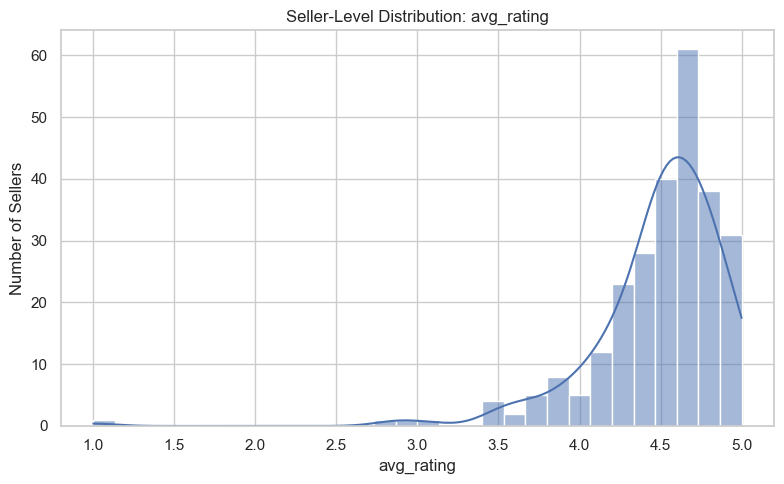

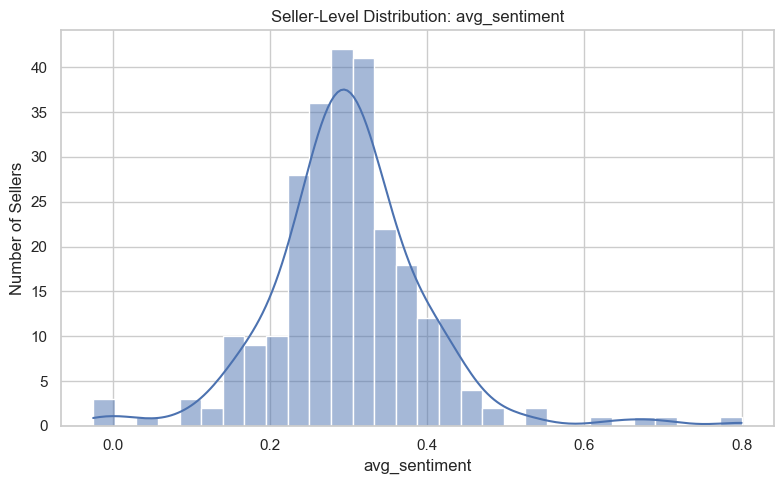

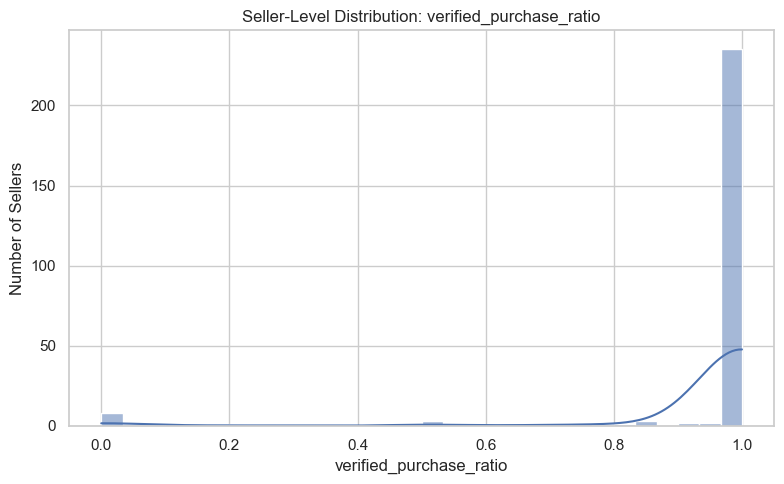

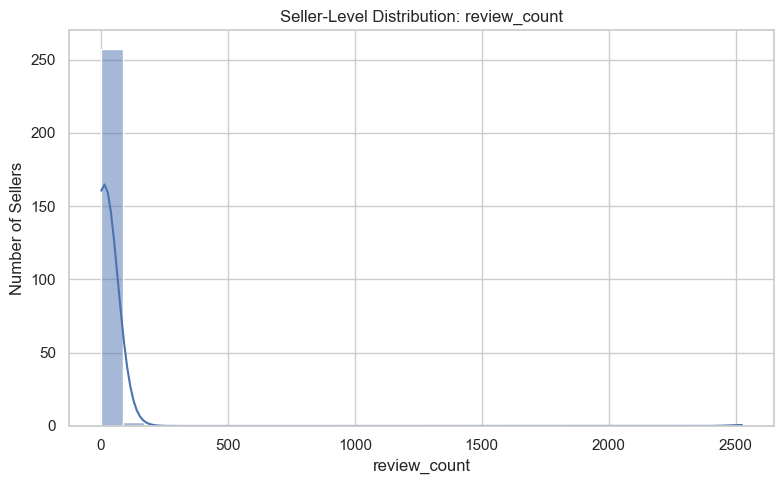

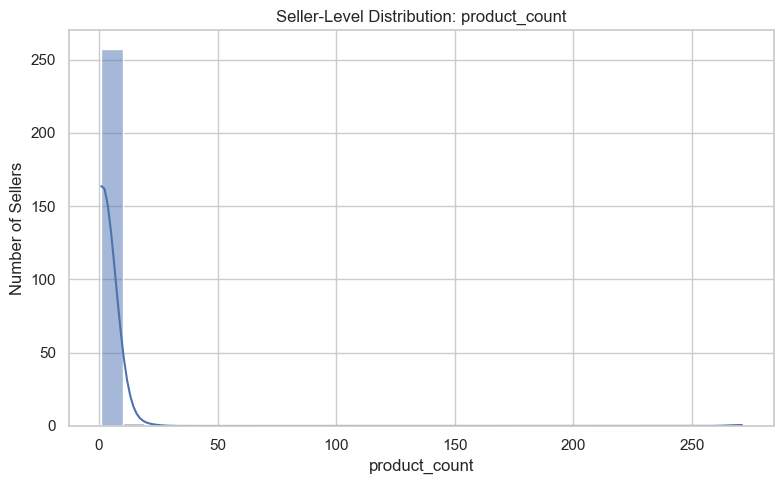

In [46]:
# Seller feature distributions

if "seller_level_preview" in globals():
    seller_feature_cols = [
        "avg_rating",
        "avg_sentiment",
        "avg_helpful_vote",
        "verified_purchase_ratio",
        "review_count",
        "product_count"
    ]

    for col in seller_feature_cols:
        if col in seller_level_preview.columns:
            plt.figure(figsize=(8, 5))
            sns.histplot(seller_level_preview[col].dropna(), bins=30, kde=True)
            plt.title(f"Seller-Level Distribution: {col}")
            plt.xlabel(col)
            plt.ylabel("Number of Sellers")
            plt.tight_layout()
            plt.show()

,seller_name,avg_rating,avg_sentiment,verified_purchase_ratio,review_count,product_count
15,Amazon.com,4.6657,0.3133,0.9945,2525,271
53,Dokotoo Flagship Shop,4.4338,0.3190,1.0000,136,15
151,PAATM SHIVA,3.9810,0.2766,0.9810,105,15
256,unknown,3.8190,0.3434,1.0000,105,19
40,COOFANDY,4.4167,0.3131,0.9306,72,8
192,SuperiorBrands,4.2857,0.2673,1.0000,70,7
25,Automet-US,4.5538,0.2891,1.0000,65,7
169,Real Essentials,4.4375,0.2519,1.0000,64,7
239,ZITY®,4.4754,0.2921,0.8361,61,7
153,PRETTYGARDEN,4.4000,0.2779,1.0000,60,6


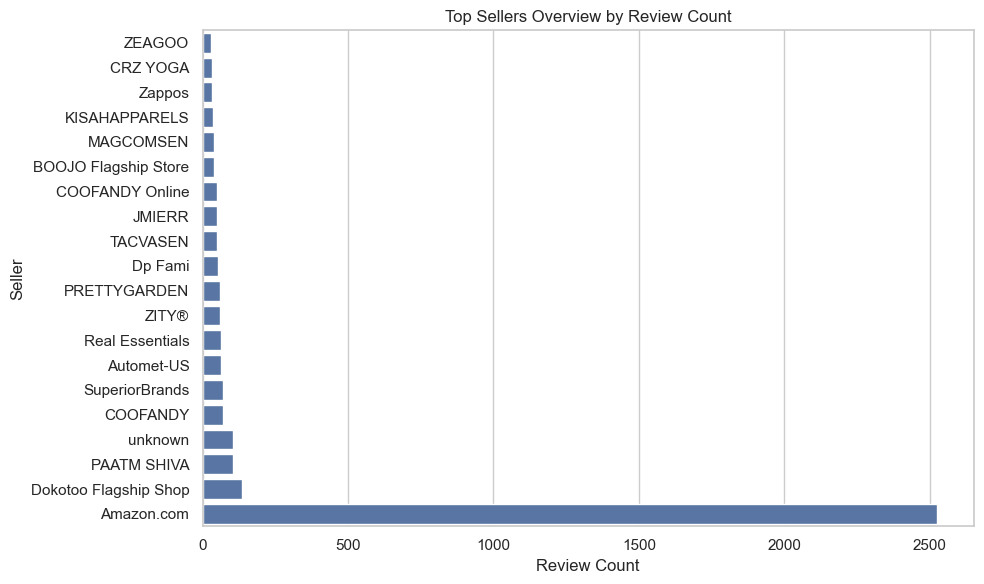

In [47]:
# Top sellers overview

if "seller_level_preview" in globals():
    if "review_count" in seller_level_preview.columns:
        top_sellers_overview = (
            seller_level_preview
            .sort_values("review_count", ascending=False)
            .head(20)
        )

        display(top_sellers_overview)

        plt.figure(figsize=(10, 6))
        sns.barplot(
            data=top_sellers_overview.sort_values("review_count"),
            x="review_count",
            y="seller_name"
        )
        plt.title("Top Sellers Overview by Review Count")
        plt.xlabel("Review Count")
        plt.ylabel("Seller")
        plt.tight_layout()
        plt.show()

## Kết luận phần 9

Seller-level preview cho thấy dataset có thể được tổng hợp ở cấp seller nếu `seller_name`, `reviewid`, `productasin`, `rating`, `sentiment_score` và `verifiedpurchase` đủ đầy đủ.

Các biến aggregate như `avg_rating`, `avg_sentiment`, `review_count`, `product_count` và `verified_purchase_ratio` có tiềm năng hỗ trợ xây dựng seller-level dataset ở notebook tiếp theo.

# PHẦN 10. EXECUTIVE SUMMARY

Phần này tổng hợp các phát hiện chính từ EDA và đề xuất hướng triển khai cho notebook tiếp theo.

Notebook hiện tại chỉ dừng ở phân tích khám phá, không thực hiện ESG scoring hoặc machine learning.

In [48]:
# Executive summary tables

display_section_title("PHẦN 10. EXECUTIVE SUMMARY")

summary_items = {
    "number_of_records": df.shape[0],
    "number_of_columns": df.shape[1],
    "unique_products": safe_nunique(df, "productasin"),
    "unique_sellers": safe_nunique(df, "seller_name"),
    "unique_brands": safe_nunique(df, "brand_name"),
    "unique_reviews": safe_nunique(df, "reviewid"),
    "avg_rating": df["rating"].mean() if "rating" in df.columns else None,
    "avg_sentiment": df["sentiment_score"].mean() if "sentiment_score" in df.columns else None,
    "avg_review_length": df["review_length"].mean() if "review_length" in df.columns else None,
}

executive_summary_df = pd.DataFrame.from_dict(
    summary_items,
    orient="index",
    columns=["value"]
)

display(executive_summary_df)


PHẦN 10. EXECUTIVE SUMMARY


,value
number_of_records,6327.0000
number_of_columns,35.0000
unique_products,700.0000
unique_sellers,261.0000
unique_brands,278.0000
unique_reviews,6327.0000
avg_rating,4.5337
avg_sentiment,0.3075
avg_review_length,206.7493


In [49]:
# Final check

print("EDA notebook completed successfully.")
print("Dataset used:", INPUT_PATH)
print("Final dataset shape:", df.shape)

if "seller_level_preview" in globals():
    print("Seller-level preview shape:", seller_level_preview.shape)

EDA notebook completed successfully.
Dataset used: c:\Users\ASPIRE 7\OneDrive\Tài liệu\UEH\CTD2026_DT049\Dataset\processed\cleaned_amazon_dataset.csv
Final dataset shape: (6327, 35)
Seller-level preview shape: (261, 6)
